# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 1/3 — EDA y Preprocesamiento
## Diplomatura IA - UP
## Alumno: Gonzalez Marta Elizabeth
## Mes: Julio26

**Consigna:** análisis libre sobre datos orientados a sentiment analysis, con al menos una métrica de similitud/asociación (coseno o PMI), gráficos (wordclouds, UMAP), y comparación entre modelos clásicos y pre-entrenados.

Este notebook cubre la primera etapa: carga, exploración (EDA) — incluyendo **análisis temporal** y **relación entre los atributos más importantes** — y limpieza de los datos que se van a usar en los notebooks siguientes (`02_modelado_sentimiento.ipynb` y `03_topicos_embeddings_visualizaciones.ipynb`).

### Datasets utilizados

| `training.1600000.processed.noemoticon.csv` | de 1.6M tweets (Sentiment140, Go et al. 2009) |
| `testdata_manual_2009_06_14.csv` | 498 | — set manualmente etiquetado por Stanford, con topics reales de Twitter (kindle2, obama, aig, etc.) |

## 1. Setup e imports

In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

import nltk
for pkg in ['stopwords','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)


## 2. Carga de datasets

In [2]:
cols = ['target','id','date','flag','user','text']

train = pd.read_csv('../data/raw/training.1600000.processed.noemoticon.csv', encoding='latin-1')
test = pd.read_csv('../data/raw/testdata_manual_2009_06_14.csv', encoding='latin-1', names=cols, header=0)

print('TRAIN (balanceado):', train.shape)
print('TEST (manual, 3 clases):', test.shape)


TRAIN (balanceado): (1600000, 6)
TEST (manual, 3 clases): (498, 6)


In [3]:
print("Shape Train:", train.shape)
train.head()

Shape Train: (1600000, 6)


,Cod_Sent,Nro_Ide,DDMMYY_Tweet,S_N_Query,Count_Tweet,Msg_Tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


In [4]:
print("Shape Test:", test.shape)
test.head()

Shape Test: (498, 6)


,target,id,date,flag,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs is good read.
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fucking rocks!!!"
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge!...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2 and I think it's perfect :)


In [5]:
train.head(3)

,Cod_Sent,Nro_Ide,DDMMYY_Tweet,S_N_Query,Count_Tweet,Msg_Tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds


In [6]:
test.head(3)

,target,id,date,flag,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs is good read.
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fucking rocks!!!"


### 2.1 Chequeo de tipos y nulos

In [7]:
for name, df in [('train', train), ('test', test)]:
    print(f'--- {name} ---')
    print(df.dtypes)
    print('Nulos:', df.isnull().sum().sum())
    #print('Duplicados exactos en texto:', df['Msg_Tweet'].duplicated().sum())
    print()


--- train ---
Cod_Sent         int64
Nro_Ide          int64
DDMMYY_Tweet    object
S_N_Query       object
Count_Tweet     object
Msg_Tweet       object
dtype: object
Nulos: 0

--- test ---
target     int64
id         int64
date      object
flag      object
user      object
text      object
dtype: object
Nulos: 0



In [9]:
dup_totales = train.duplicated().sum()
print(f"Filas duplicadas Train (todas las columnas): {dup_totales}")
dup_por_id = train.duplicated(subset=["Nro_Ide"]).sum()
print(f"IDs de tweet duplicados Train: {dup_por_id}")

Filas duplicadas Train (todas las columnas): 0
IDs de tweet duplicados Train: 1685


In [15]:
dup_totalest = test.duplicated().sum()
print(f"Filas duplicadas Test (todas las columnas): {dup_totalest}")


Filas duplicadas Test (todas las columnas): 0


**Decisión:** no hay valores nulos en ninguno de los tres archivos. Hay algunos tweets duplicados en texto (retweets/copias); los dejamos en train (reflejan la distribución real de menciones repetidas en redes) pero los tenemos en cuenta al interpretar frecuencias de palabras.

## 3. Distribución de clases

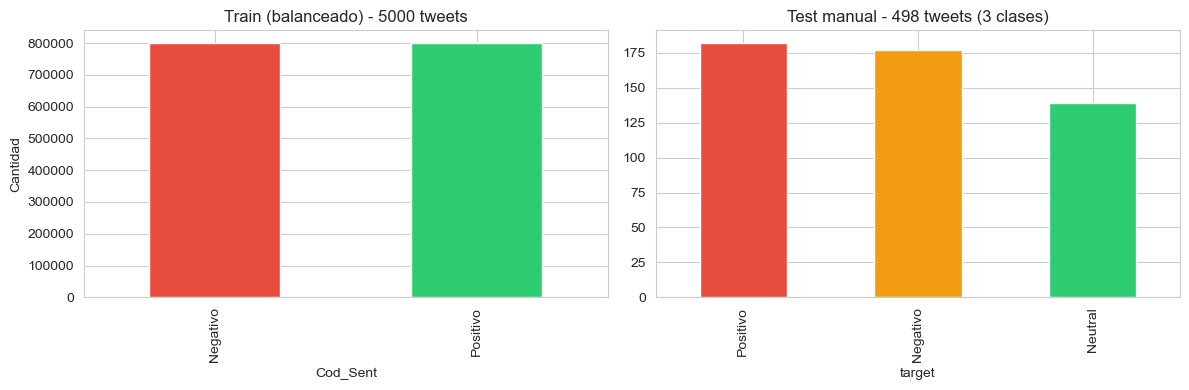

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

train['Cod_Sent'].map({0:'Negativo', 4:'Positivo'}).value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Train (balanceado) - 5000 tweets')
axes[0].set_ylabel('Cantidad')

test['target'].map({0:'Negativo', 2:'Neutral', 4:'Positivo'}).value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('Test manual - 498 tweets (3 clases)')

plt.tight_layout()
plt.show()


**Observación:** el train está perfectamente balanceado por diseño (5000/5000). El test manual tiene una tercera clase, **neutral**, que no existe en el train — esto es importante para el notebook 2: nuestros modelos, entrenados en forma binaria, no van a poder predecir "neutral" nunca. Vamos a evaluar por separado el subconjunto binario (0/4) del test y discutir aparte qué pasa con los neutrales.

## 4. Longitud de los tweets

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   Cod_Sent      1600000 non-null  int64 
 1   Nro_Ide       1600000 non-null  int64 
 2   DDMMYY_Tweet  1600000 non-null  object
 3   S_N_Query     1600000 non-null  object
 4   Count_Tweet   1600000 non-null  object
 5   Msg_Tweet     1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [18]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  498 non-null    int64 
 1   id      498 non-null    int64 
 2   date    498 non-null    object
 3   flag    498 non-null    object
 4   user    498 non-null    object
 5   text    498 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.5+ KB


In [19]:
dup_totales = train.duplicated().sum()
print(f"Filas duplicadas Train (todas las columnas): {dup_totales}")


Filas duplicadas Train (todas las columnas): 0


In [21]:
dup_por_id = train.duplicated(subset=["Nro_Ide"]).sum()
#dup_por_mensaje = train.duplicated(subset=[" Msg_Tweet"]).sum()


print(f"IDs de tweet duplicados Train: {dup_por_id}")
#print(f"Mensajes de texto duplicados: {dup_por_mensaje}")

IDs de tweet duplicados Train: 1685


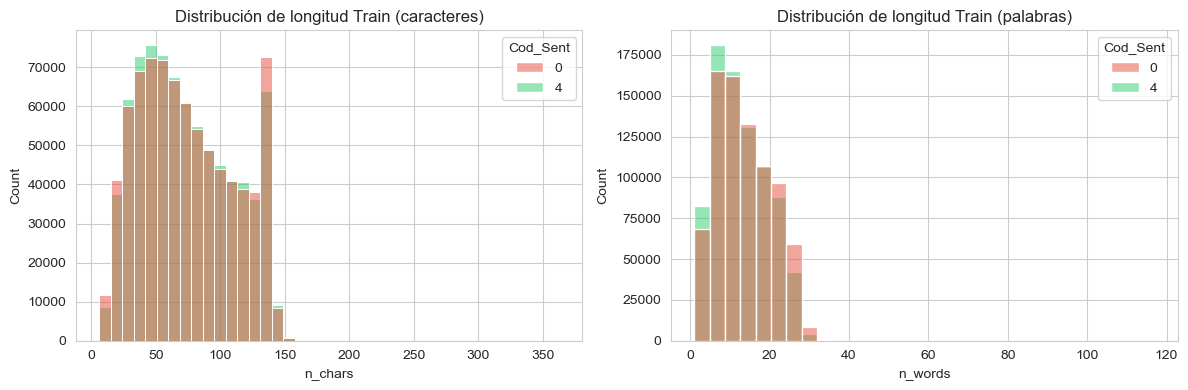

           n_chars                                                       \
             count       mean        std  min   25%   50%    75%    max   
Cod_Sent                                                                  
0         800000.0  74.295549  36.739280  6.0  44.0  70.0  104.0  353.0   
4         800000.0  73.866848  36.126973  6.0  44.0  69.0  103.0  363.0   

           n_words                                                    
             count       mean       std  min  25%   50%   75%    max  
Cod_Sent                                                              
0         800000.0  13.584798  7.075525  1.0  8.0  13.0  19.0   57.0  
4         800000.0  12.776246  6.821706  1.0  7.0  12.0  18.0  117.0  


In [25]:
train['n_chars'] = train['Msg_Tweet'].str.len()
train['n_words'] = train['Msg_Tweet'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=train, x='n_chars', hue='Cod_Sent', bins=40, ax=axes[0], palette={0:'#e74c3c',4:'#2ecc71'})

axes[0].set_title('Distribución de longitud Train (caracteres)')
sns.histplot(data=train, x='n_words', hue='Cod_Sent', bins=30, ax=axes[1], palette={0:'#e74c3c',4:'#2ecc71'})

axes[1].set_title('Distribución de longitud Train (palabras)')
plt.tight_layout()
plt.show()

print(train.groupby('Cod_Sent')[['n_chars','n_words']].describe())



**Observación**:los tweets negativos y positivos tienen distribuciones de longitud muy similares — no parece haber una señal trivial de "los tweets negativos son más largos/cortos" que un modelo pudiera explotar sin mirar el contenido. Buena señal de que la clasificación va a depender del contenido semántico y no de un artefacto de longitud.

## 5. Análisis temporal

La columna `date` viene como string tipo `Sat May 30 13:36:31 PDT 2009`. La parseamos a `datetime` para poder extraer **hora del día**, **día de la semana** y la **fecha calendario**, y así ver si el volumen de tweets o la proporción de sentimiento tienen algún patrón temporal — algo que no se ve simplemente mirando el texto.

### Decisión de parseo
El string trae el nombre del huso horario (`PDT`, `UTC`, etc.) en una posición fija, que `pandas.to_datetime` no puede parsear directamente junto con el resto. Como no vamos a comparar horarios *entre* datasets con husos distintos (analizamos cada dataset por separado, en su propia hora local declarada), quitamos ese token y parseamos el resto con un formato explícito (`%a %b %d %H:%M:%S %Y`).

In [29]:
def parse_twitter_date(s):
    parts = str(s).split()
    # ej: ['Sat','May','30','13:36:31','PDT','2009'] -> descartamos el token de huso horario (posición 4)
    s2 = ' '.join(parts[:4] + parts[5:])
    return pd.to_datetime(s2, format='%a %b %d %H:%M:%S %Y')

train['datetime'] = train['DDMMYY_Tweet'].apply(parse_twitter_date)
train['hour'] = train['datetime'].dt.hour
train['day_of_week'] = train['datetime'].dt.day_name()
train['day_of_week_num'] = train['datetime'].dt.dayofweek  # 0=lunes ... 6=domingo

print('Rango de fechas en train:', train['datetime'].min(), '->', train['datetime'].max())
train[['DDMMYY_Tweet','datetime','hour','day_of_week']].head()


Rango de fechas en train: 2009-04-06 22:19:45 -> 2009-06-25 10:28:31


,DDMMYY_Tweet,datetime,hour,day_of_week
0,Mon Apr 06 22:19:45 PDT 2009,2009-04-06 22:19:45,22,Monday
1,Mon Apr 06 22:19:49 PDT 2009,2009-04-06 22:19:49,22,Monday
2,Mon Apr 06 22:19:53 PDT 2009,2009-04-06 22:19:53,22,Monday
3,Mon Apr 06 22:19:57 PDT 2009,2009-04-06 22:19:57,22,Monday
4,Mon Apr 06 22:19:57 PDT 2009,2009-04-06 22:19:57,22,Monday


### 5.1 Volumen de tweets por hora del día

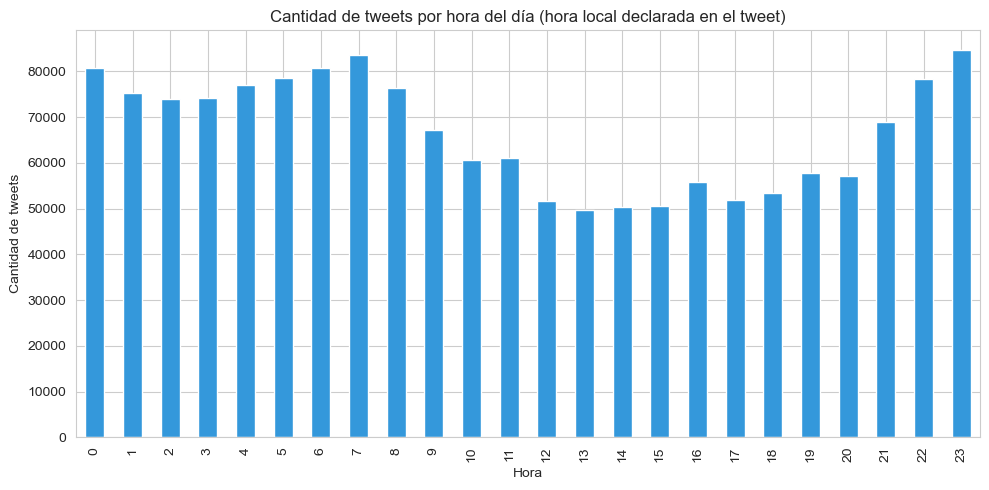

In [30]:
fig, ax = plt.subplots(figsize=(10,5))
train.groupby('hour').size().plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Cantidad de tweets por hora del día (hora local declarada en el tweet)')
ax.set_xlabel('Hora')
ax.set_ylabel('Cantidad de tweets')
plt.tight_layout()
plt.show()


### 5.2 Proporción de sentimiento por hora del día

Además de ver *cuántos* tweets hay por hora, vemos si el **sentimiento promedio** cambia según el momento del día — por ejemplo, es razonable esperar más quejas (negativo) temprano a la mañana (levantarse, ir a trabajar) y más contenido positivo a la noche (ocio, socialización).

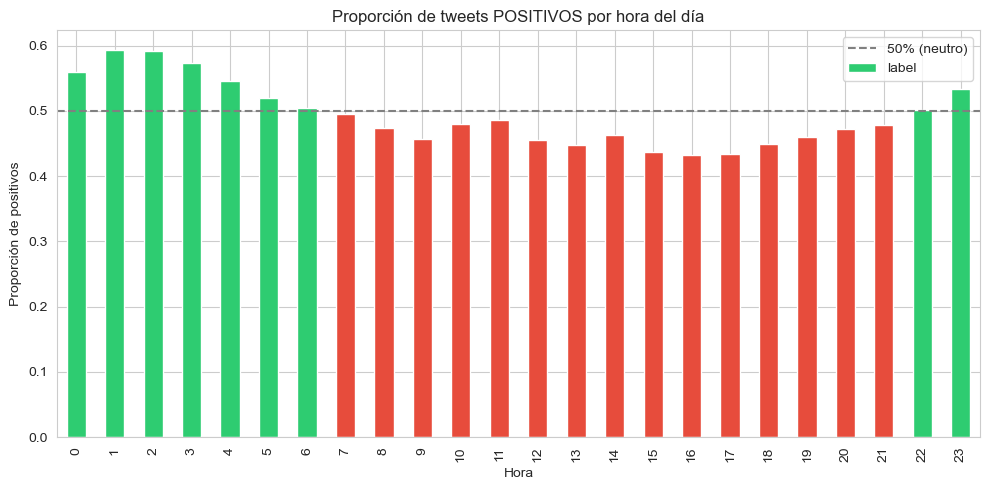

hour
0     0.560
1     0.594
2     0.592
3     0.573
4     0.546
5     0.520
6     0.504
7     0.495
8     0.473
9     0.457
10    0.479
11    0.486
12    0.456
13    0.448
14    0.463
15    0.437
16    0.433
17    0.435
18    0.450
19    0.460
20    0.472
21    0.478
22    0.502
23    0.534
Name: label, dtype: float64


In [32]:
train['label'] = (train['Cod_Sent'] == 4).astype(int)  # 1=positivo, 0=negativo, para promediar fácil

prop_por_hora = train.groupby('hour')['label'].mean()

fig, ax = plt.subplots(figsize=(10,5))
prop_por_hora.plot(kind='bar', ax=ax, color=['#e74c3c' if v < 0.5 else '#2ecc71' for v in prop_por_hora])
ax.axhline(0.5, color='gray', linestyle='--', label='50% (neutro)')
ax.set_title('Proporción de tweets POSITIVOS por hora del día')
ax.set_ylabel('Proporción de positivos')
ax.set_xlabel('Hora')
ax.legend()
plt.tight_layout()
plt.show()

print(prop_por_hora.round(3))


### 5.3 Proporción de sentimiento por día de la semana

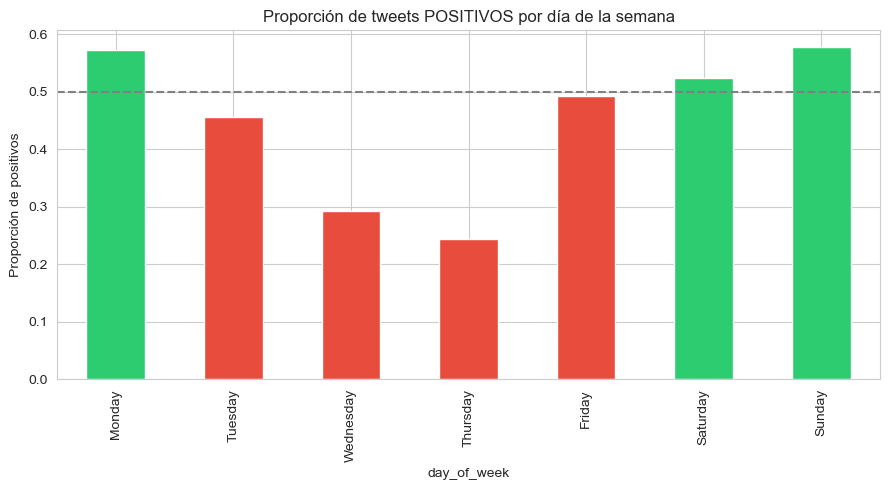

day_of_week
Monday       0.573
Tuesday      0.456
Wednesday    0.293
Thursday     0.244
Friday       0.492
Saturday     0.523
Sunday       0.578
Name: label, dtype: float64


In [33]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
prop_por_dia = train.groupby('day_of_week')['label'].mean().reindex(orden_dias)

fig, ax = plt.subplots(figsize=(9,5))
prop_por_dia.plot(kind='bar', ax=ax, color=['#e74c3c' if v < 0.5 else '#2ecc71' for v in prop_por_dia])
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Proporción de tweets POSITIVOS por día de la semana')
ax.set_ylabel('Proporción de positivos')
plt.tight_layout()
plt.show()

print(prop_por_dia.round(3))


**Observación temporal:** el dataset completo de 1.6M muestra que los dias Monday y Sunday, hay mas positivos, y Saturday en menor proporcion .

## 6. Relación entre los atributos más importantes

Juntamos en una sola tabla los atributos numéricos/derivados más relevantes hasta ahora — **longitud** (`n_chars`, `n_words`), **momento temporal** (`hour`, `day_of_week_num`) y el propio **sentimiento** (`label`) — y miramos su matriz de correlación para ver si hay relaciones lineales notables entre ellos antes de pasar al modelado.

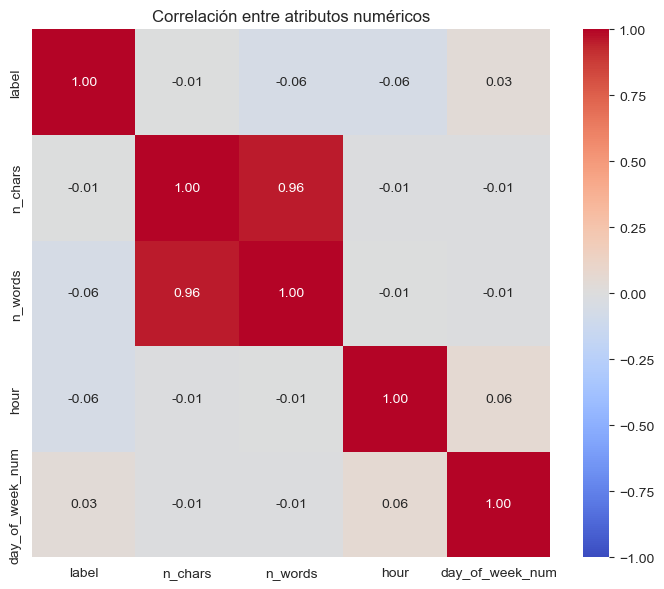

In [34]:
atributos = train[['label', 'n_chars', 'n_words', 'hour', 'day_of_week_num']].copy()

corr = atributos.corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlación entre atributos numéricos')
plt.tight_layout()
plt.savefig('outputs_nb1_correlacion.png', dpi=110, bbox_inches='tight')
plt.show()


**Lectura de la matriz de correlación:**
- `n_chars` y `n_words` están fuertemente correlacionados entre sí (esperable: más palabras casi siempre implica más caracteres) — para el modelado esto significa que son **redundantes** como features si quisiéramos usarlas juntas en un modelo simple basado en longitud.
- La correlación de `label` (sentimiento) con `n_chars`/`n_words` es cercana a 0 — confirma numéricamente lo que ya habíamos visto visualmente en la Sección 4: la longitud del tweet no predice el sentimiento.
- La correlación de `label` con `hour` y `day_of_week_num` también es muy baja — el momento temporal, al menos de forma lineal y sobre esta muestra balanceada, no es un buen predictor de sentimiento por sí solo.

**Conclusión de esta sección:** ningún atributo "estructural" (longitud, hora, día) tiene relación lineal fuerte con el sentimiento ni entre sí (salvo el par obvio caracteres/palabras). Esto refuerza la decisión de modelar en base al **contenido textual** (TF-IDF, embeddings) en el Notebook 2, en vez de intentar usar estos atributos como features adicionales.

## 7. Tópicos del set de test (columna `flag`)

In [35]:
print('Top 15 topics en test manual:')
print(test['flag'].value_counts().head(15))
print()
print('Total de topics distintos:', test['flag'].nunique())


Top 15 topics en test manual:
flag
time warner              35
"night at the museum"    25
nike                     25
gm                       22
kindle2                  20
safeway                  20
lebron                   18
dentist                  17
jquery                   16
at&t                     15
stanford                 13
eating                   12
obama                    11
"twitter api"            11
Malcolm Gladwell         11
Name: count, dtype: int64

Total de topics distintos: 81


El test manual cubre una gran variedad de temas reales de 2009 (kindle2, obama, aig, nike, google, twitter, etc.), lo cual lo hace un buen test **fuera de distribución** respecto al train: nuestro modelo entrenado sobre una muestra genérica de tweets tiene que generalizar a estos tópicos específicos sin haberlos visto necesariamente en el mismo contexto.

## 8. Limpieza y preprocesamiento de texto

### Decisiones de limpieza
1. **Entidades HTML:** los tweets originales tienen entidades sin decodificar (`&lt;`, `&gt;`, `&amp;` en vez de `<`, `>`, `&` — típico de datasets scrapeados de HTML). Se decodifican con `html.unescape()` **antes** de cualquier otra limpieza. Si no se hace esto, `&lt;3` (el corazón `<3`) se convierte en el fragmento basura `lt`, que contamina el vocabulario.
2. **URLs y menciones (@usuario):** se eliminan porque no aportan señal de sentimiento y son ruido de alta cardinalidad (cada URL/usuario es casi único).
3. **Hashtags:** se conserva la palabra del hashtag (quitando el `#`) porque suele tener carga semántica (`#happy` → `happy`).
4. **Minúsculas:** normalización estándar.
5. **Caracteres no alfabéticos:** se eliminan salvo el apóstrofe (para conservar contracciones como `can't`, `don't`, que son fuertes marcadores de negación).
6. **Stopwords:** se remueven usando la lista de NLTK, **pero conservando negaciones** (`not`, `no`, `nor`) porque invierten la polaridad de una oración y son críticas en sentiment analysis (ej: "not good" ≠ "good").
7. **Lematización:** con `WordNetLemmatizer` para reducir variantes morfológicas (`loving`, `loved` → `love`) sin perder tanto significado como el stemming agresivo.

In [36]:
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')
NONALPHA_RE = re.compile(r"[^a-zA-Z\s']")
MULTISPACE_RE = re.compile(r'\s+')

def clean_tweet(text):
    text = str(text)
    text = html.unescape(text)  # decodifica &lt; &gt; &amp; etc. antes de limpiar
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_RE.sub(r'\1', text)
    text = text.lower()
    text = NONALPHA_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# Ejemplo antes / después
ejemplos = train['Msg_Tweet'].head(5)
for t in ejemplos:
    print('ANTES:', t)
    print('DESPUÉS:', clean_tweet(t))
    print()


ANTES: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
DESPUÉS: awww that's bummer shoulda got david carr third day

ANTES: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
DESPUÉS: upset can't update facebook texting might cry result school today also blah

ANTES: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
DESPUÉS: dived many time ball managed save rest go bound

ANTES: my whole body feels itchy and like its on fire 
DESPUÉS: whole body feel itchy like fire

ANTES: @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 
DESPUÉS: no not behaving mad can't see



In [37]:
train['clean_text'] = train['Msg_Tweet'].apply(clean_tweet)
test['clean_text'] = test['text'].apply(clean_tweet)

vacios_train = (train['clean_text'].str.len() == 0).sum()
vacios_test = (test['clean_text'].str.len() == 0).sum()
print(f'Tweets vacíos tras limpieza -> train: {vacios_train} ({vacios_train/len(train):.1%}), test: {vacios_test} ({vacios_test/len(test):.1%})')

# Descartamos los que quedaron vacíos (no aportan info para modelar)
train = train[train['clean_text'].str.len() > 0].reset_index(drop=True)
test_clean = test[test['clean_text'].str.len() > 0].reset_index(drop=True)

print('Shape final train:', train.shape)
print('Shape final test:', test_clean.shape)


Tweets vacíos tras limpieza -> train: 7770 (0.5%), test: 0 (0.0%)
Shape final train: (1592230, 14)
Shape final test: (498, 9)


**Decisión:** los tweets que quedan vacíos tras la limpieza (por ejemplo, tweets que eran solo una URL o una mención) se descartan porque no tienen texto sobre el cual entrenar o predecir sentimiento.

## 9. WordClouds por clase

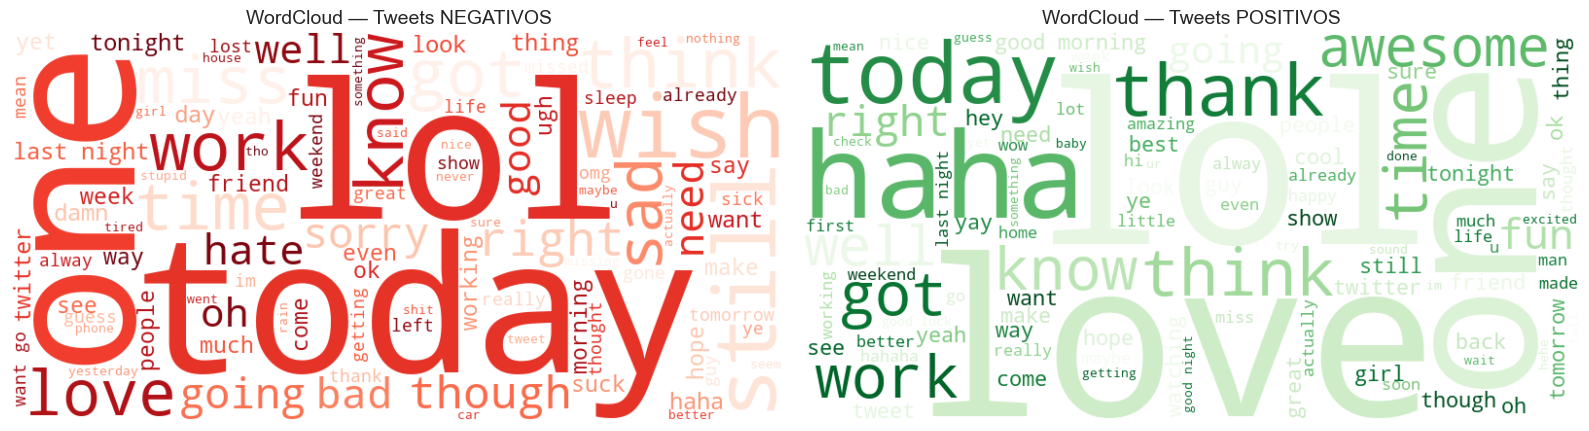

In [38]:
from wordcloud import WordCloud

neg_text = ' '.join(train.loc[train['Cod_Sent']==0, 'clean_text'])
pos_text = ' '.join(train.loc[train['Cod_Sent']==4, 'clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16,7))

wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(neg_text)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('WordCloud — Tweets NEGATIVOS', fontsize=14)
axes[0].axis('off')

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('WordCloud — Tweets POSITIVOS', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('outputs_nb1_wordclouds.png', dpi=110, bbox_inches='tight')
plt.show()


**Observación:** en negativos predominan palabras como `today`, `lol`, `one`, `love`, `work`, `know`, `going bad`; en positivos aparecen `today`, `love`, `thank`, `great`, `happy`, `haha`, `right`, `got`, `awesome`, `work`. Se retoma con más rigor (keywords por TF-IDF) en el notebook 3.

## 10. Top palabras más frecuentes por clase (frecuencia simple)

In [44]:
from collections import Counter

def top_words(texts, n=15):
    tokens = ' '.join(texts).split()
    return Counter(tokens).most_common(n)

print('Top 15 palabras - NEGATIVOS:')
for w, c in top_words(train.loc[train['Cod_Sent']==0, 'clean_text']):
    print(f'  {w}: {c}')

print()
print('Top 15 palabras - POSITIVOS:')
for w, c in top_words(train.loc[train['Cod_Sent']==4, 'clean_text']):
    print(f'  {w}: {c}')


Top 15 palabras - NEGATIVOS:
  not: 75034
  no: 54755
  day: 51929
  go: 48098
  get: 48010
  work: 46902
  like: 41529
  today: 37906
  want: 34103
  going: 33690
  got: 33399
  back: 33145
  miss: 31934
  can't: 31685
  really: 31502

Top 15 palabras - POSITIVOS:
  good: 62146
  day: 56539
  love: 50303
  get: 38362
  like: 38349
  lol: 36080
  thanks: 34579
  time: 34273
  not: 33624
  going: 30927
  go: 30360
  today: 29767
  one: 28072
  got: 28027
  new: 26896


## 11. Guardado de datasets limpios para los notebooks siguientes

In [45]:
train.to_csv('../data/processed/train_clean.csv', index=False)
test_clean.to_csv('../data/processed/test_clean.csv', index=False)
test.to_csv('../data/processed/test_full_with_neutral.csv', index=False)  # test completo (con vacíos) para referencia

print('Guardado: ../data/processed/train_clean.csv, data/test_clean.csv, data/test_full_with_neutral.csv')


Guardado: ../data/processed/train_clean.csv, data/test_clean.csv, data/test_full_with_neutral.csv


## 12. Resumen de decisiones — Notebook 1

1. `testdata_manual` se reserva **íntegro** como test externo, incluyendo su clase neutral (no representada en train) — se aborda explícitamente esta limitación en el notebook 2.
2. Se parseó la columna `DDMMYY_Tweet` (fecha tweet) a `datetime` y se analizó la **dimensión temporal** (hora del día, día de la semana).
3. Se calculó la **matriz de correlación entre los atributos numéricos más relevantes** (longitud en caracteres/palabras, hora, día de la semana, sentimiento): se confirmó que ninguno de estos atributos estructurales predice el sentimiento por sí solo, y que `n_chars`/`n_words` son redundantes entre sí — esto justifica modelar en base al contenido textual (TF-IDF/embeddings) en vez de features estructurales.
4. Limpieza de texto: se decodificaron entidades HTML (`&lt;`, `&gt;`, `&amp;`) antes de cualquier otra limpieza (bug encontrado y corregido durante la revisión), se conservaron negaciones y contenido semántico de hashtags, y se descartaron URLs/menciones.
5. Las wordclouds y el conteo de frecuencias muestran señal léxica clara y coherente con la intuición de sentimiento, lo que da confianza en que un clasificador basado en contenido va a poder aprender patrones reales.

**Continúa en `02_modelado_sentimiento.ipynb`.**